# Rattay-Aberham Axon Model

This notebook implements and tests the **Rattay-Aberham** Hodgkin-Huxley type model for mammalian axons, based on the published parameters for 37°C. 

Source: [modelDB](https://modeldb.science/266498?tab=2&file=PelotEtAl_JNP_2020_Models/MultiCompartmentModels/Mod/RattayAberham.mod)

## 1. Model 

The Rattay-Aberham model describes sodium, potassium, and leak currents across the axon membrane:

$
C_m \frac{dV}{dt} = I_\text{inj} - (I_\text{Na} + I_\text{K} + I_\text{L})
$

where:

- $V$ = membrane potential (mV)  
- $C_m$ = membrane capacitance (µF/cm²)  
- $I_\text{inj}$ = injected current (µA/cm²)  
- $I_\text{Na}, I_\text{K}, I_\text{L}$ = ionic currents (µA/cm²)

> Note: Currents in the original mod are in mA/cm².


## 2. Ionic Currents

### Sodium Current

$$
I_\text{Na} = g_\text{Na} \, m^3 h \, (V - E_\text{Na})
$$

- $g_\text{Na}$ = maximal sodium conductance (S/cm²)  
- $m$ = activation gating variable  
- $h$ = inactivation gating variable  
- $E_\text{Na}$ = sodium reversal potential (mV)  

### Potassium Current

$
I_\text{K} = g_\text{K} \, n^4 \, (V - E_\text{K})
$

- $g_\text{K}$ = maximal potassium conductance (S/cm²)  
- $n$ = potassium activation gating variable  
- $E_\text{K}$ = potassium reversal potential (mV)  

### Leak Current

$
I_\text{L} = g_\text{L} \, (V - E_\text{L})
$

- $g_\text{L}$ = leak conductance (S/cm²)  
- $E_\text{L}$ = leak reversal potential (mV)


## 3. Gating Variable Dynamics

The gating variables \(m, h, n follow first-order kinetics:

$$
\frac{dm}{dt} = \frac{m_\infty(V) - m}{\tau_m(V)}, \quad
\frac{dh}{dt} = \frac{h_\infty(V) - h}{\tau_h(V)}, \quad
\frac{dn}{dt} = \frac{n_\infty(V) - n}{\tau_n(V)}
$$

Where the steady-state values and time constants are:

$$
x_\infty(V) = \frac{\alpha_x(V)}{\alpha_x(V) + \beta_x(V)}, \quad
\tau_x(V) = \frac{1}{q_{10} \, (\alpha_x(V) + \beta_x(V))}, \quad x \in \{m,h,n\}
$$

> **Q10 temperature factor** for Rattay-Aberham (k=12):  
$$
q_{10} = 2.24659524757^{(T-6.3)/10}, \quad T=37°C
$$

The rate functions $\alpha$ and $\beta$ are voltage-dependent:

$$
\alpha_m = \frac{2.5 - 0.1(V+70)}{1 - \exp(-(2.5 - 0.1(V+70)) / 1)}, \quad
\beta_m = 4 \exp(-(V+70)/18)
$$

$$
\alpha_h = 0.07 \exp(-(V+70)/20), \quad
\beta_h = \frac{1}{\exp(3 - 0.1(V+70)) + 1}
$$

$$
\alpha_n = 0.1 \frac{1 - 0.1(V+70)}{1 - \exp(-(1 - 0.1(V+70)) / 1)}, \quad
\beta_n = 0.125 \exp(-(V+70)/80)
$$

## 5. Python implementation

### Required packages and helpers


In [14]:
import numpy as np
import matplotlib.pyplot as plt

def vtrap(x, y):            #to avoid near zero division
    z = x / y
    small = np.abs(z) < 1e-6
    return np.where(small, y * (1 - z / 2), x / (np.exp(z) - 1))

### Simulation Parameters

In [15]:
dt = 0.01  # ms
T = 37.0   # °C
tmax = 15  # ms

### Model Parameters

In [16]:
C_m = 1.0  # µF/cm²

# Conductances (S/cm²)
gnabar = 0.12
gkbar = 0.036
gl = 0.0003

# Reversal potentials (mV)
ena = 50.0
ek = -77.0
el = -59.4

# Q10 factor
q10 = 2.24659524757**((T - 6.3)/10)

### Gating variables rate equations

In [17]:
def rates(V):
    # Sodium m
    alpha_m = vtrap(2.5 - 0.1*(V+70), 1)
    beta_m = 4 * np.exp(-(V+70)/18)
    mtau = 1 / (q10 * (alpha_m + beta_m))
    minf = alpha_m / (alpha_m + beta_m)
    # Sodium h
    alpha_h = 0.07 * np.exp(-(V+70)/20)
    beta_h = 1 / (np.exp(3 - 0.1*(V+70)) + 1)
    htau = 1 / (q10 * (alpha_h + beta_h))
    hinf = alpha_h / (alpha_h + beta_h)
    # Potassium n
    alpha_n = 0.1 * vtrap(1 - 0.1*(V+70), 1)
    beta_n = 0.125 * np.exp(-(V+70)/80)
    ntau = 1 / (q10 * (alpha_n + beta_n))
    ninf = alpha_n / (alpha_n + beta_n)
    return minf, mtau, hinf, htau, ninf, ntau


### Time vector and initial conditions

In [18]:

t = np.arange(0, tmax, dt)
V = np.zeros_like(t)
m = np.zeros_like(t)
h = np.zeros_like(t)
n = np.zeros_like(t)
I_Na = np.zeros_like(t)
I_K = np.zeros_like(t)
I_L = np.zeros_like(t)

V[0] = el
minf, mtau, hinf, htau, ninf, ntau = rates(V[0])
m[0] = minf
h[0] = hinf
n[0] = ninf

### Current Injection: 1 ms pulse

In [19]:
I_inj = np.zeros_like(t)
I_inj[(t > 5) & (t < 6)] = 100e-3  # mA/cm², convert to µA/cm² later

### Euler integration

In [20]:

for i in range(1, len(t)):
    minf, mtau, hinf, htau, ninf, ntau = rates(V[i-1])
    
    # update gating variables
    m[i] = m[i-1] + dt * (minf - m[i-1]) / mtau
    h[i] = h[i-1] + dt * (hinf - h[i-1]) / htau
    n[i] = n[i-1] + dt * (ninf - n[i-1]) / ntau
    
    # compute currents in mA/cm²
    gna = gnabar * m[i]**3 * h[i]
    gk = gkbar * n[i]**4
    ina = gna * (V[i-1] - ena)
    ik = gk * (V[i-1] - ek)
    il = gl * (V[i-1] - el)
    
    # convert to µA/cm² for physiological magnitude
    I_ion = (ina + ik + il) * 1e3
    
    # membrane equation
    V[i] = V[i-1] + dt * (I_inj[i]*1e3 - I_ion) / C_m
    
    # store currents in µA/cm²
    I_Na[i] = ina*1e3
    I_K[i] = ik*1e3
    I_L[i] = il*1e3

### Plot results

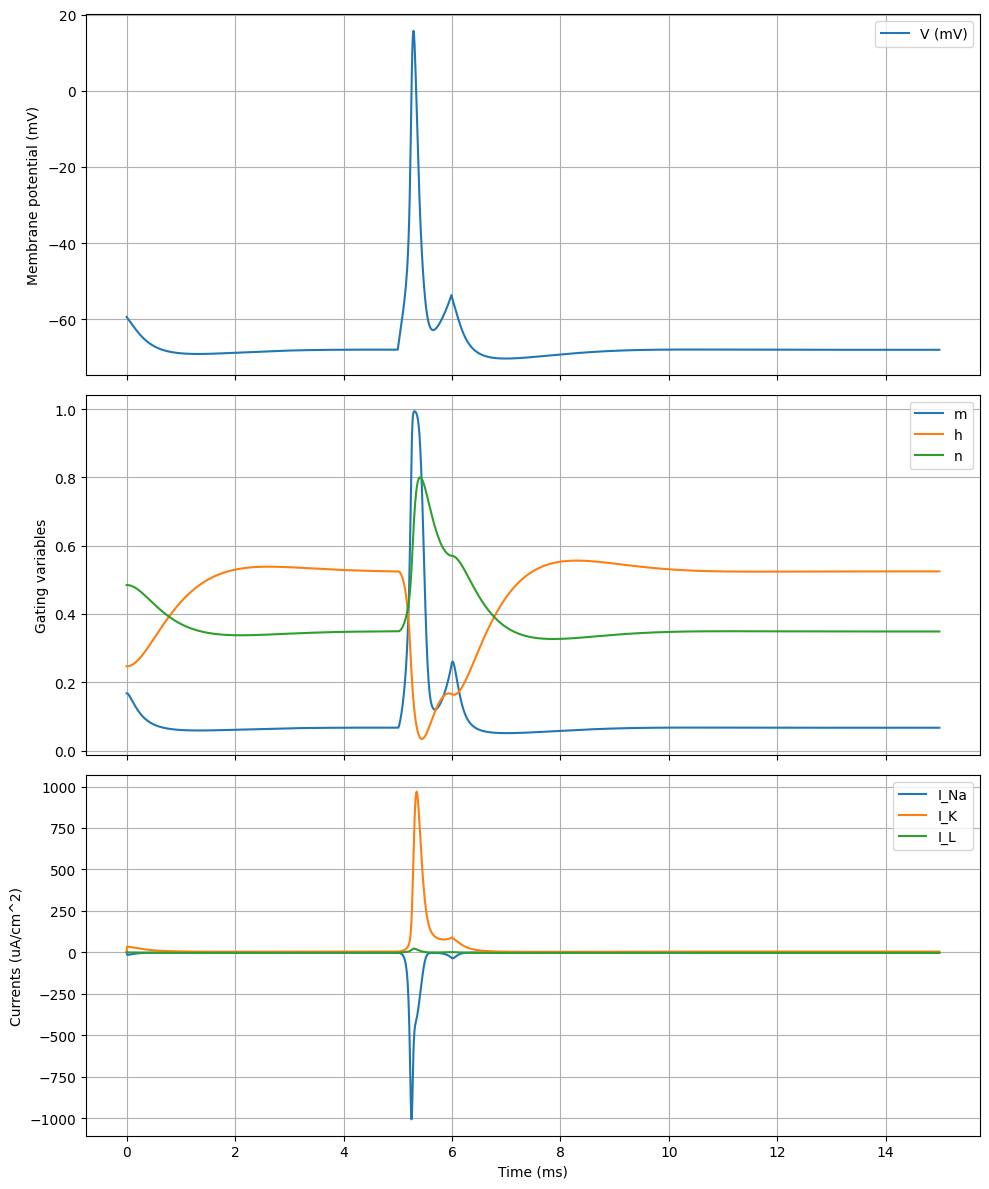

In [22]:
fig, axs = plt.subplots(3, 1, figsize=(10, 12), sharex=True)

# Voltage
axs[0].plot(t, V, label='V (mV)')
axs[0].set_ylabel('Membrane potential (mV)')
axs[0].legend()
axs[0].grid(True)

# Gating variables
axs[1].plot(t, m, label='m')
axs[1].plot(t, h, label='h')
axs[1].plot(t, n, label='n')
axs[1].set_ylabel('Gating variables')
axs[1].legend()
axs[1].grid(True)

# Currents
axs[2].plot(t, I_Na, label='I_Na')
axs[2].plot(t, I_K, label='I_K')
axs[2].plot(t, I_L, label='I_L')
axs[2].set_ylabel('Currents (uA/cm^2)')
axs[2].set_xlabel('Time (ms)')
axs[2].legend()
axs[2].grid(True)

fig.tight_layout()